# Step 1: Implement the vector gradient.

Implement the vector gradient as described in the lecture slides and the assignment description in the `color_sobel_edges()` function below.  Use sobel filters to estimate partial derivatives.  Use the `color_dot_product()` function (provided) to compute the necessary dot products to obtain gxx, gyy, and gxy.  Return an array containing the gradient magnitudes for each pixel, i.e. a graident magnitude image.  Optionally, return a second array containing the gradient directions for each pixel.

As usual, the input image must be dtype `float` or `uint8`.  If it is `uint8` convert it to `float` before processing.  Leave the magnitude image ouput as dtype `float` regardless of the input's dtype.



In [5]:
import skimage.util as util
import skimage.io as io
import matplotlib.pyplot as plt
import numpy as np


def color_dot_product(A, B):
    '''
    Element-by-element dot product in a 2D array of vectors.

    :return: An array in which index [i,j,:] is the dot product of A[i,j,:] and B[i,j,:].
    '''
    return np.sum(A.conj()*B, axis=2)



def color_sobel_edges(I):
    '''
    Finish me!
    
    :param I: Input image
    :return: A tuple of an array containing the gradient magnitudes for each pixel 
    and an array containing the gradient directions for each pixel
    '''
    
    img = I
    
    # convert uint8 to float
    if I.dtype == "uint8":
        img = util.img_as_float(I)
   
    u_red = filt.sobel_v(img[:, :, 0])
    u_green = filt.sobel_v(img[:, :, 1])
    u_blue = filt.sobel_v(img[:, :, 2])

    v_red = filt.sobel_h(img[:, :, 0])
    v_green = filt.sobel_h(img[:, :, 1])
    v_blue = filt.sobel_h(img[:, :, 2])
    
    u = np.dstack((u_red, u_green, u_blue))
    v = np.dstack((v_red, v_green, v_blue))
    
    # computing gxx, gyy, gxy
    gxx = color_dot_product(u, u)
    gyy = color_dot_product(v, v)
    gxy = color_dot_product(u, v)
    
    # computing gradient direction
    g_direction = (1/2)*np.arctan2(2*gxy, (gxx - gyy))

    # computing gradient magnitude
    g_magnitude = np.power(((1/2)*((gxx + gyy) 
                                   + (gxx - gyy)*np.cos(2*g_direction) 
                                   + 2*gxy*np.sin(2*g_direction))), (1/2))
    
    return g_magnitude, g_direction

# Step 2: Examine behavior of the kurtosis sharpness metric.

Write a function which:

* takes as input an input image, a minimum value of sigma, and a maximum value of sigma.
* applies different amounts of Gaussian blur to the original image for all integer values of sigma between the provided minimum and maximum values of sigma, inclusive. (reminder: sigma describes the standard deviation of the gaussian filter mask used to blur the image).
* For each blurred image, compute the gradient magnitude using `color_sobel_edges()`, then compute compute the kurtosis sharpness measure.  This is the log(kurtosis+3) where kurtosis is the kurtosis of the gradient magnitude image of the blurred image as described in the assignment description document.  See `scipy.stats.kurtosis()`.
* Returns a tuple consisting of the range object of sigma values used and the list of computed kurtosis values for each sigma.

Call the function using `mushroom.jpg` as the input image, a minimum sigma of 1, and a maximum sigma of 30.  Use a smaller max sigma until you are sure it's working, then increase to 30, as it can take a few minutes to do all the filtering.  Use the return values from your function to plot a line graph of gaussian blur sigma vs. blur measure (kurtosis) for the waterfall image.  Add appropriate axis labels and a descriptive title.  Sample output is provided in the assignment description document.



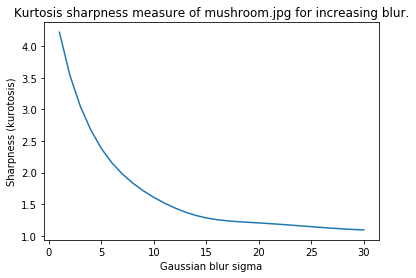

In [7]:
import skimage.filters as skfilt
import skimage.filters as filt
import scipy.stats as stats
% matplotlib inline

def test_blur_measure(I, min_sigma, max_sigma):
    '''
    Finish me!
    
    :param I: Input image
    :param min_sigma: Minimum sigma value for gaussian blur
    :param max_sigma: Maximum sigma value for gaussian blur
    :return: A tuple of a range object of sigma values used and 
    a list of computed kurtosis values for each sigma
    '''
    
    K_list = []
    
    for i in range(min_sigma, max_sigma+1):
        img = skfilt.gaussian(I, sigma=i, multichannel=True)
        gmag = color_sobel_edges(img)
        gmag_reshape = np.reshape(gmag[0], -1)
        K = stats.kurtosis(gmag_reshape)
        K_list.append(np.log(K+3))
        
    return range(min_sigma, max_sigma+1), K_list


mushroom = io.imread('mushroom.jpg')
result = test_blur_measure(mushroom, 1, 30)
plt.plot(result[0], result[1])
plt.ylabel('Sharpness (kurotosis)')
plt.xlabel('Gaussian blur sigma')
plt.title('Kurtosis sharpness measure of mushroom.jpg for increasing blur.')
plt.show()

# Step 3:  Create a local blur map

Write a function which:

* takes as input an input image and a square window size (in pixels). e.g. if `window_size = 11`, this means an 11 by 11 window.
* computes the local sharpness of the input image (i.e. log(kurtosis+3)) for each tiled, non-overlapping square window of the given window size
* stores each local sharpness in an array where each entry represents one window of the input image (the size of this array can be computed by integer division of the original image dimensions by the window size)
* returns the array of local sharpnesses.

Then call the function you just wrote with `mushroom.jpg` as the input image and 100 as the window size.  Plot the returned array as an image using `plt.imshow()`.  Do not rescale this image with `vmin=` or `vmax=`, and use the default colormap (don't change it to `'gray'`).  Add a color scale bar to the figure using `plt.colorbar()`.  Sample output is provided in the assignment description document.



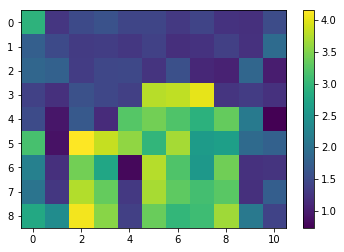

In [62]:
def sharpness_map(I, window_size):
    '''
    
    Finish me!
    
    :param I: Input image
    :param window_size: Dimension of window
    :return: Array of local sharpnesses
    '''
    
    
    result = []

    for i in range(0, len(I), window_size):
        temp_list = []
        for j in range(0, len(I[0]), window_size):
            window = I[i:i+window_size, j:j+window_size]
            w_gradient = color_sobel_edges(window)[0]
            w_reshape = np.reshape(w_gradient, w_gradient.shape[0]*w_gradient.shape[1])
            K = stats.kurtosis(w_reshape)
            temp = np.log(K+3)
            temp_list.append(temp)
        result.append(temp_list)
        
    return result


result = sharpness_map(mushroom, 100)
plt.imshow(result)
plt.colorbar()
plt.show()

# Step 4: Try it on another image.

Use the functions you wrote to produce the same plots as in steps 2 and 3 but for the `waterfall.jpg` image instead.


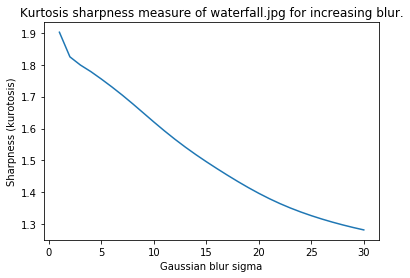

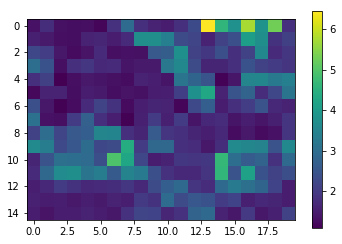

In [63]:
# Write your code here.

# waterfall sharpness chart
waterfall = io.imread('waterfall.jpg')
waterfall_graph = test_blur_measure(waterfall, 1, 30)
plt.plot(waterfall_graph[0], waterfall_graph[1])
plt.ylabel('Sharpness (kurotosis)')
plt.xlabel('Gaussian blur sigma')
plt.title('Kurtosis sharpness measure of waterfall.jpg for increasing blur.')
plt.show()

# waterfall blur map
waterfall_map = sharpness_map(waterfall, 100)
plt.imshow(waterfall_map)
plt.colorbar()
plt.show()

# Step 5: Thinking and Qualitative Analysis

### Answer the following questions, right here in this block.

1. Do you think that the log(kurtosis+3) measurement of sharpness (hereafter called the "sharpness measure") is a good measure for characterizing global image blur (the general amount that the entire image is blurred)?  Explain and justify your answer.

	_Your answer:_  Generally yes I think it is a good measure for global image blur because for both the mushroom and waterfall image the graph shows that the sharpness measurement decreases as more gaussian blur is applied to the image. It also seems like other information about the global image blur can be inferred but it is not as clear. Looking closely the mushroom image started with a higher measure and plateaued earlier could suggest that there is a location where the image is very sharp but once blurred to a certain point the sharpness measure of the entire image is very low. On the other hand, the waterfall image started with a lower overall sharpness measure, suggesting that there isn't a part of the image that is particularly sharp but instead the extent of its sharpness is pretty equal within the entire image, it also has a gradual decrease in sharpness which also suggests that there is not one part of the image that was more sharp than another.

2. Is the sharpness measure effective at characterizing variations in local blur?  Does it respond to different regions of images appropriately?  Explain and justify your answers.

	_Your answer:_  For the mushroom image, it was effective in characterizing variations in local blur. The regions in the forefront where there are clear mushrooms is mostly yellow which stands for the highest sharpness measure while the blurred background is mostly blue and purples which correspond to low sharpness measure. However, it was not as effective pinpointing sharpness in the waterfall image as most of the image is characterized as lower sharpness measure which isn't necessarily true when looking at the actual waterfall.jpg, but instead it seems it can't differeniate areas of sharpness in the picture when the entire image is similar in sharpness.

3. Think of what the shape of a histogram of gradient magnitudes would look like for a sharp image.  Why does this set of gradient magnitudes have high kurtosis?  (It might help to look up kurtosis and see what it measures about a histogram!)

	_Your answer:_  Kurtosis is a measure of whether the data are heavy-tailed or light-tailed relative to a normal distribution. A high kurtosis represents heavy tails or having outliers. Because the image is sharp there will be difference between the sharp and less sharp pixels and therefore causing the existence of outliers. That is why this set of gradient magnitudes have high kurtosis.

4. Now think what would happen as that same image gets blurrier.  Explain how the shape of the histogram would change, and the corresponding effect on the kurtosis.

	_Your answer:_  The shape of the histogram will have less heavy tails and the kurtosis would be lower as the image gets blurrier, there will be less sharp points in the image and therefore less difference between pixels.